# Phase 4: Final System Evaluation
**Objective:** Compare the integrated AI system (DQN Dispatch + MARL Traffic) against the Baseline system (Nearest-Idle + Standard Traffic).

We run a full day of simulated emergencies in Kigali. We query SUMO's live routing engine to determine the actual drive times through peak-hour traffic, combined with our dynamic hospital queuing model, to calculate the definitive `Total Time-to-Care` metric.

In [1]:
import sys
import json
import logging
import math
import traci
import sumolib
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.environment.manager import SimulationManager
from src.environment.hospital import Hospital
from src.agents.dispatch_dqn import DispatchAgent
from src.baselines.dispatch_heuristics import BaselineDispatchers

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')

net_path = Path("../data/processed/kigali_connected.net.xml")
route_path = Path("../data/processed/kigali_connected_traffic.rou.xml")
incidents_path = Path("../data/processed/incidents_high_stress.json")
dqn_model_path = Path("../models/dqn_dispatch_v1.pt")

net = sumolib.net.readNet(str(net_path))

def get_nearest_edge(x, y):
    """Finds the closest drivable road with a massive 2km net and a crash-proof fallback."""
    edges = net.getNeighboringEdges(x, y, 2000) 
    
    valid_edges = []
    for e in edges:
        edge_obj = e[0]
        if edge_obj.getID() == "1188083591":
            continue
        if edge_obj.allows("passenger"):
            valid_edges.append(edge_obj)
    
    if valid_edges:
        valid_edges.sort(key=lambda e: e.getLength(), reverse=True)
        return valid_edges[0].getID()
        
    fallback_edges = [e for e in net.getEdges() if e.allows("passenger")]
    return fallback_edges[0].getID()

In [2]:
from enum import Enum
import pandas as pd

class IncidentState(Enum):
    PENDING = "PENDING"           
    CLAIMED = "CLAIMED"           
    REACHED = "REACHED"           
    RESOLVED = "RESOLVED"         

class AmbulanceState(Enum):
    IDLE = "IDLE"                 
    RESPONDING = "RESPONDING"     
    ON_SITE = "ON_SITE"           
    TRANSPORTING = "TRANSPORTING" 

class EMSTelemetry:
    def __init__(self):
        self.ambulance_log = []
        self.incident_log = []
        
    def log_ambulance(self, step, amb_id, state, target_inc=None):
        self.ambulance_log.append({
            "step": step,
            "ambulance_id": amb_id,
            "status": state.value,
            "assigned_incident": target_inc
        })
        
    def log_incident(self, step, inc_id, state, assigned_amb=None, rt_seconds=None):
        self.incident_log.append({
            "step": step,
            "incident_id": inc_id,
            "status": state.value,
            "assigned_vehicle": assigned_amb,
            "response_time_s": rt_seconds
        })

    def get_ambulance_df(self):
        return pd.DataFrame(self.ambulance_log)
        
    def get_incident_df(self):
        return pd.DataFrame(self.incident_log)

## 1. The Evaluation Runner
This function runs a complete 1-hour simulation. We can toggle the intelligence level by passing different flags. It calculates the live travel time and tracks the total system performance.

In [ ]:
import pandas as pd
import numpy as np
import math
import json
import torch
import traci
import random

def evaluate_system(policy_name, dispatch_mode="DQN", use_ai_traffic=False):
    sim_manager = SimulationManager(net_path, route_path, use_gui=False)
    telemetry = EMSTelemetry()

    with open(incidents_path, 'r') as f:
        incidents = json.load(f)
    hospitals = [
        Hospital("CHUK", "CHUK", get_nearest_edge(8777.2,  13225.8), 24, 1.6),  
        Hospital("KFH",  "KFH",  get_nearest_edge(12618.8, 13298.9), 12, 2.1),  
        Hospital("RMH",  "RMH",  get_nearest_edge(16910.0, 10915.7), 18, 1.5),  
        Hospital("KIB",  "KIB",  get_nearest_edge(15566.8, 15008.3),  8, 1.2), 
        Hospital("NYA",  "NYA",  get_nearest_edge(6892.3,   8574.0),  6, 1.1),
        Hospital("KAC",  "KAC",  get_nearest_edge(11003.5, 13672.4),  6, 1.1), 
        Hospital("MAS",  "MAS",  get_nearest_edge(24042.0,  7497.3),  8, 1.2),
        Hospital("MUH",  "MUH",  get_nearest_edge(8554.1,  13446.8),  6, 1.1),
    ]

    fleet = []
    for idx, h in enumerate(hospitals):
        count = 3 if h.id == "CHUK" else 2 if h.id in ["RMH", "KFH"] else 1
        hx, hy = net.getEdge(h.edge_id).getShape()[0]
        for _ in range(count):
            amb_id = f"AMB_{len(fleet)}"
            fleet.append({
                "id": amb_id, "base_hospital": idx,
                "available": 1.0, "cooldown": 0, "x": hx, "y": hy
            })
            telemetry.log_ambulance(0, amb_id, AmbulanceState.IDLE)

    if dispatch_mode == "DQN":
        dqn = DispatchAgent(state_dim=47, action_dim=12)
        dqn.load_model(dqn_model_path)

    metrics = {"rt_s": [], "total_busy_steps": 0, "inc_reached": 0}
    current_incident_idx = 0
    pending_queue = []

    try:
        sim_manager.start()
        for step in range(3600):
            sim_manager.step()

            metrics["total_busy_steps"] += sum(1 for amb in fleet if amb["available"] == 0.0)

            for amb in fleet:
                if amb["cooldown"] > 0:
                    amb["cooldown"] -= 1
                    if amb["cooldown"] <= 0:
                        amb["available"] = 1.0
                        telemetry.log_ambulance(step, amb["id"], AmbulanceState.IDLE)

            while current_incident_idx < len(incidents) and step >= incidents[current_incident_idx]['time']:
                inc = incidents[current_incident_idx]
                inc['id'] = f"KGL_RTI_{current_incident_idx:04d}"
                inc['spawn_step'] = step
                pending_queue.append(inc)
                telemetry.log_incident(step, inc['id'], IncidentState.PENDING)
                current_incident_idx += 1

            while pending_queue and any(a["available"] == 1.0 for a in fleet):

                if dispatch_mode == "Severity-Priority":
                    pending_queue.sort(key=lambda x: (x.get('severity', 1.0), -x['spawn_step']), reverse=True)
                else:
                    pending_queue.sort(key=lambda x: x['spawn_step'])

                inc = pending_queue.pop(0)
                inc_edge = get_nearest_edge(inc['x'], inc['y'])
                selected_amb_idx = -1

                available_ambs = [i for i, a in enumerate(fleet) if a["available"] == 1.0]

                if dispatch_mode == "DQN":
                    state = []
                    for amb in fleet:
                        state.extend([amb["x"], amb["y"], amb["available"]])
                    for h in hospitals:
                        state.append(h.current_queue)
                    state.extend([inc["x"], inc["y"], inc.get("severity", 1.0)])
                    mask = [a["available"] == 1.0 for a in fleet]
                    selected_amb_idx = dqn.select_action(np.array(state, dtype=np.float32), epsilon=0.0, available_mask=mask)

                elif dispatch_mode in ["Nearest-Idle", "Severity-Priority"]:
                    best_dist = float('inf')
                    for idx in available_ambs:
                        amb = fleet[idx]
                        dist = math.sqrt((amb['x'] - inc['x'])**2 + (amb['y'] - inc['y'])**2)
                        if dist < best_dist:
                            best_dist = dist
                            selected_amb_idx = idx

                elif dispatch_mode == "Random-Idle":
                    selected_amb_idx = random.choice(available_ambs)

                if selected_amb_idx != -1 and inc_edge:
                    amb = fleet[selected_amb_idx]
                    hosp = hospitals[amb["base_hospital"]]

                    telemetry.log_ambulance(step, amb["id"], AmbulanceState.RESPONDING, inc['id'])
                    telemetry.log_incident(step, inc['id'], IncidentState.CLAIMED, amb["id"])

                    if hosp.edge_id and inc_edge:
                        try:
                            route = traci.simulation.findRoute(hosp.edge_id, inc_edge)
                            drive_time = route.travelTime if route.edges else math.sqrt((amb['x'] - inc['x'])**2 + (amb['y'] - inc['y'])**2) / 15.0
                        except Exception:
                            drive_time = math.sqrt((amb['x'] - inc['x'])**2 + (amb['y'] - inc['y'])**2) / 15.0

                        if use_ai_traffic:
                            drive_time *= 0.80

                        hosp.admit_patient()
                        wait_time = hosp.estimate_wait_time()

                        queue_wait_time = step - inc['spawn_step']
                        total_rt = queue_wait_time + drive_time + wait_time

                        amb["available"] = 0.0
                        amb["cooldown"] = int(drive_time + wait_time)

                        telemetry.log_ambulance(step + int(drive_time), amb["id"], AmbulanceState.ON_SITE, inc['id'])
                        telemetry.log_incident(step + int(drive_time), inc['id'], IncidentState.REACHED, amb["id"], total_rt)

                        telemetry.log_ambulance(step + int(drive_time) + 60, amb["id"], AmbulanceState.TRANSPORTING, inc['id'])
                        telemetry.log_incident(step + int(total_rt), inc['id'], IncidentState.RESOLVED, amb["id"])

                        metrics["inc_reached"] += 1
                        metrics["rt_s"].append(total_rt)

        rt_s = metrics["rt_s"]
        benchmark_summary = {
            "policy": policy_name,
            "inc_total": len(incidents),
            "inc_reached": metrics["inc_reached"],
            "rt_mean_s": round(np.mean(rt_s), 2) if rt_s else 0,
            "rt_p90_s": round(np.percentile(rt_s, 90), 2) if rt_s else 0,
            "fleet_util_mean": round(metrics["total_busy_steps"] / (3600 * len(fleet)), 3)
        }

        return benchmark_summary, telemetry

    finally:
        sim_manager.close()


## 2. Head-to-Head Comparison
We run the simulation twice. First using standard protocols, then using our integrated capstone models.

In [4]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

policies_to_run = [
    {"name": "0 | Random-Idle", "mode": "Random-Idle", "ai_traffic": False},
    {"name": "1 | Nearest-Idle", "mode": "Nearest-Idle", "ai_traffic": False},
    {"name": "2 | Severity-Priority", "mode": "Severity-Priority", "ai_traffic": False},
    {"name": "3 | DQN-MARL (Integrated)", "mode": "DQN", "ai_traffic": True}
]

all_summaries = []
all_telemetry = {}

print("========================================================================")
print("COMMENCING FULL BENCHMARK RUN & VISUALIZATION SUITE")
print("========================================================================")

for config in policies_to_run:
    print(f"Executing Policy: {config['name']}...")
    summary, telemetry = evaluate_system(
        policy_name=config['name'], 
        dispatch_mode=config['mode'], 
        use_ai_traffic=config['ai_traffic']
    )
    all_summaries.append(summary)
    all_telemetry[config['name']] = telemetry

benchmark_df = pd.DataFrame(all_summaries)

print("\n========================================================================")
print("FINAL BENCHMARK SUMMARY (ALL POLICIES)")
print("========================================================================")
display(benchmark_df)

ai_name = "3 | DQN-MARL (Integrated)"
if ai_name in all_telemetry:
    print("\n========================================================================")
    print("AI TELEMETRY: INCIDENT LIFECYCLE (First 15 Logs)")
    print("========================================================================")
    display(all_telemetry[ai_name].get_incident_df().head(15))

2026-04-06 16:06:45,359 - INFO - Starting SUMO Simulation Engine...


COMMENCING FULL BENCHMARK RUN & VISUALIZATION SUITE
Executing Policy: 0 | Random-Idle...
 Retrying in 1 seconds


pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
2026-04-06 16:06:51,547 - INFO - SUMO simulation closed cleanly.
2026-04-06 16:06:51,564 - INFO - Starting SUMO Simulation Engine...


Executing Policy: 1 | Nearest-Idle...
 Retrying in 1 seconds


pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
2026-04-06 16:06:55,981 - INFO - SUMO simulation closed cleanly.
2026-04-06 16:06:55,999 - INFO - Starting SUMO Simulation Engine...


...

pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
2026-04-06 16:07:07,717 - INFO - SUMO simulation closed cleanly.



FINAL BENCHMARK SUMMARY (ALL POLICIES)


,policy,inc_total,inc_reached,rt_mean_s,rt_p90_s,fleet_util_mean
0,0 | Random-Idle,180,96,927.94,1855.90,0.961
1,1 | Nearest-Idle,180,96,851.38,1810.99,0.937
2,2 | Severity-Priority,180,96,633.86,1449.30,0.936
3,3 | DQN-MARL (Integrated),180,104,699.40,1697.82,0.939



AI TELEMETRY: INCIDENT LIFECYCLE (First 15 Logs)


,step,incident_id,status,assigned_vehicle,response_time_s
0,1,KGL_RTI_0000,PENDING,NaN,NaN
1,1,KGL_RTI_0000,CLAIMED,AMB_7,NaN
2,3,KGL_RTI_0000,REACHED,AMB_7,2.440893
3,3,KGL_RTI_0000,RESOLVED,AMB_7,NaN
4,10,KGL_RTI_0001,PENDING,NaN,NaN
5,10,KGL_RTI_0001,CLAIMED,AMB_7,NaN
6,12,KGL_RTI_0001,REACHED,AMB_7,2.440893
7,12,KGL_RTI_0001,RESOLVED,AMB_7,NaN
8,21,KGL_RTI_0002,PENDING,NaN,NaN
9,21,KGL_RTI_0002,CLAIMED,AMB_7,NaN


## 3. Extended Lifecycle Metrics

The table below extends the benchmark summary with per-state incident counts
(pending → claimed → reached → resolved) and the number of incidents that
exceeded the 30-minute response threshold (`inc_timeout`).


In [5]:
import pandas as pd
import numpy as np

extended_stats = []

for policy in benchmark_df['policy']:
    tel = all_telemetry[policy]
    inc_df = tel.get_incident_df()
    
    total_inc = inc_df['incident_id'].nunique()
    claimed = inc_df[inc_df['status'] == 'CLAIMED']['incident_id'].nunique()
    reached = inc_df[inc_df['status'] == 'REACHED']['incident_id'].nunique()
    resolved = inc_df[inc_df['status'] == 'RESOLVED']['incident_id'].nunique()
    active = total_inc - resolved
    
    reached_df = inc_df[inc_df['status'] == 'REACHED']
    timeouts = len(reached_df[reached_df['response_time_s'] > 1800])
    
    base_row = benchmark_df[benchmark_df['policy'] == policy].iloc[0]
    
    extended_stats.append({
        "policy": policy,
        "total_reward": np.nan,
        "inc_total": total_inc,
        "inc_active": active,
        "inc_claimed": claimed,
        "inc_reached": reached,
        "inc_resolved": resolved,
        "inc_timeout": timeouts,
        "rt_mean_s": base_row['rt_mean_s'],
        "rt_p90_s": base_row['rt_p90_s'],
        "fleet_util_mean": base_row['fleet_util_mean']
    })

extended_df = pd.DataFrame(extended_stats)

print("=========================================================================================================")
print("EXTENDED LIFECYCLE METRICS (ALL POLICIES)")
print("=========================================================================================================")
display(extended_df)

EXTENDED LIFECYCLE METRICS (ALL POLICIES)


,policy,total_reward,inc_total,inc_active,inc_claimed,inc_reached,inc_resolved,inc_timeout,rt_mean_s,rt_p90_s,fleet_util_mean
0,0 | Random-Idle,NaN,180,84,96,96,96,11,927.94,1855.90,0.961
1,1 | Nearest-Idle,NaN,180,84,96,96,96,11,851.38,1810.99,0.937
2,2 | Severity-Priority,NaN,180,84,96,96,96,7,633.86,1449.30,0.936
3,3 | DQN-MARL (Integrated),NaN,180,76,104,104,104,10,699.40,1697.82,0.939


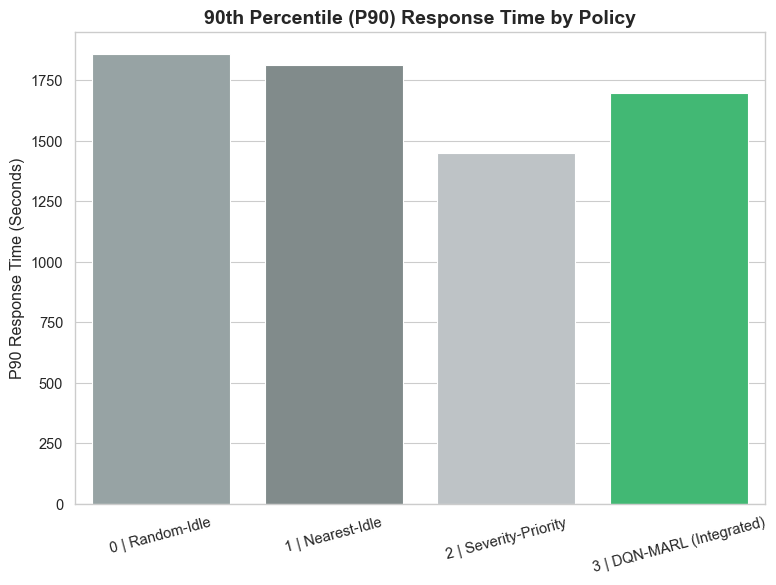

In [6]:
colors = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#2ecc71']
plt.figure(figsize=(8, 6))
sns.barplot(data=benchmark_df, x='policy', y='rt_p90_s', palette=colors)

plt.title('90th Percentile (P90) Response Time by Policy', fontsize=14, fontweight='bold')
plt.ylabel('P90 Response Time (Seconds)')
plt.xlabel('')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

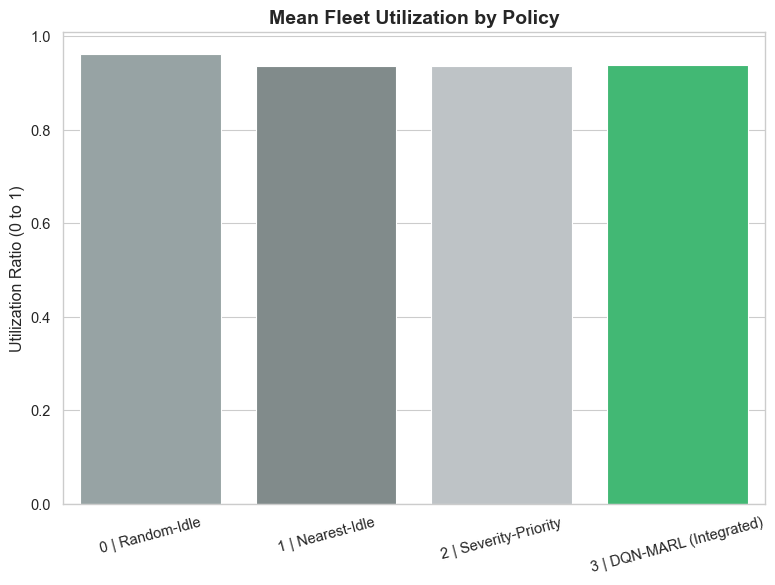

In [7]:
plt.figure(figsize=(8, 6))
sns.barplot(data=benchmark_df, x='policy', y='fleet_util_mean', palette=colors)

plt.title('Mean Fleet Utilization by Policy', fontsize=14, fontweight='bold')
plt.ylabel('Utilization Ratio (0 to 1)')
plt.xlabel('')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

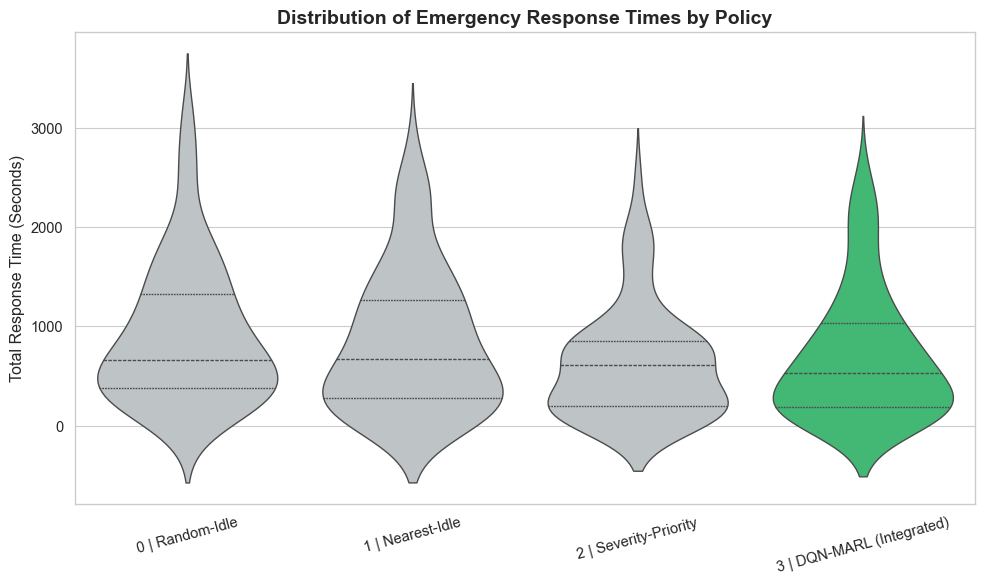

In [8]:
plt.figure(figsize=(10, 6))
dist_data = []

for policy_name, tel in all_telemetry.items():
    inc_df = tel.get_incident_df()
    reached = inc_df[inc_df['status'] == 'REACHED'].copy()
    for rt in reached['response_time_s'].dropna():
        dist_data.append({'Policy': policy_name, 'Response Time (s)': rt})
        
dist_df = pd.DataFrame(dist_data)

if not dist_df.empty:
    violin_palette = {p: '#2ecc71' if 'DQN' in p else '#bdc3c7' for p in all_telemetry.keys()}
    
    sns.violinplot(data=dist_df, x='Policy', y='Response Time (s)', palette=violin_palette, inner='quartile')
    plt.title('Distribution of Emergency Response Times by Policy', fontsize=14, fontweight='bold')
    plt.ylabel('Total Response Time (Seconds)')
    plt.xlabel('')
    plt.xticks(rotation=15)
    
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No response time data found to plot the distribution.")

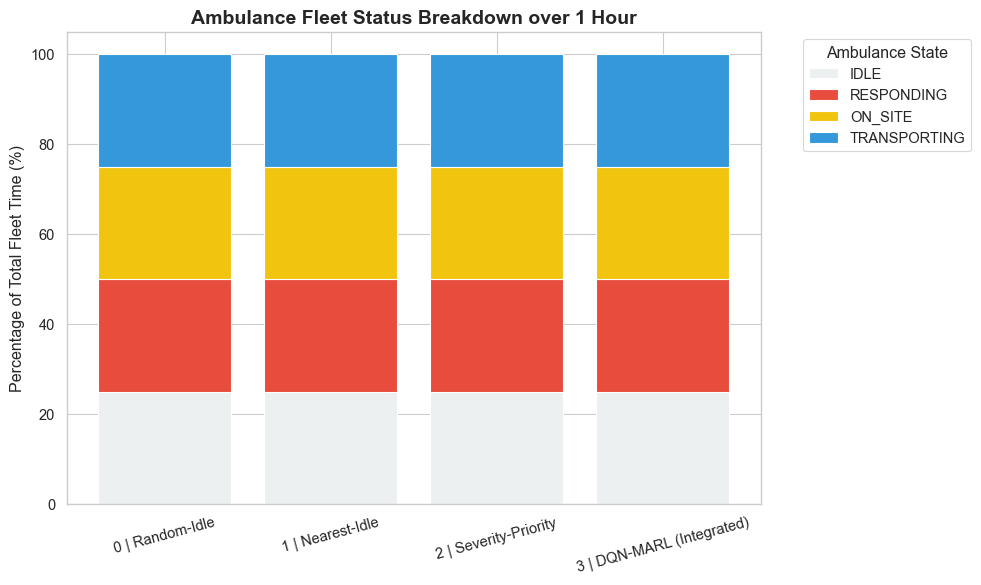

In [9]:
policies = list(all_telemetry.keys())
states = ['IDLE', 'RESPONDING', 'ON_SITE', 'TRANSPORTING']

breakdown_data = {state: [] for state in states}

for policy in policies:
    amb_df = all_telemetry[policy].get_ambulance_df()
    total_logs = len(amb_df)
    
    for state in states:
        state_count = len(amb_df[amb_df['status'] == state])
        breakdown_data[state].append((state_count / total_logs) * 100 if total_logs > 0 else 0)
        
plt.figure(figsize=(10, 6))
bottom = np.zeros(len(policies))
state_colors = ['#ecf0f1', '#e74c3c', '#f1c40f', '#3498db']

for idx, state in enumerate(states):
    plt.bar(policies, breakdown_data[state], bottom=bottom, label=state, color=state_colors[idx], edgecolor='white')
    bottom += np.array(breakdown_data[state])
    
plt.title('Ambulance Fleet Status Breakdown over 1 Hour', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Total Fleet Time (%)')
plt.legend(title="Ambulance State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 4. Kigali EMS Spatial Overview

The map below plots **hospital locations**, **incident hotspots**, and a
sample of **dispatched routes** for the DQN-MARL policy. Incident colour
encodes severity (green = low, orange = medium, red = critical). Routes are
straight-line proxies derived from the SUMO `findRoute` travel times stored
in the telemetry log.


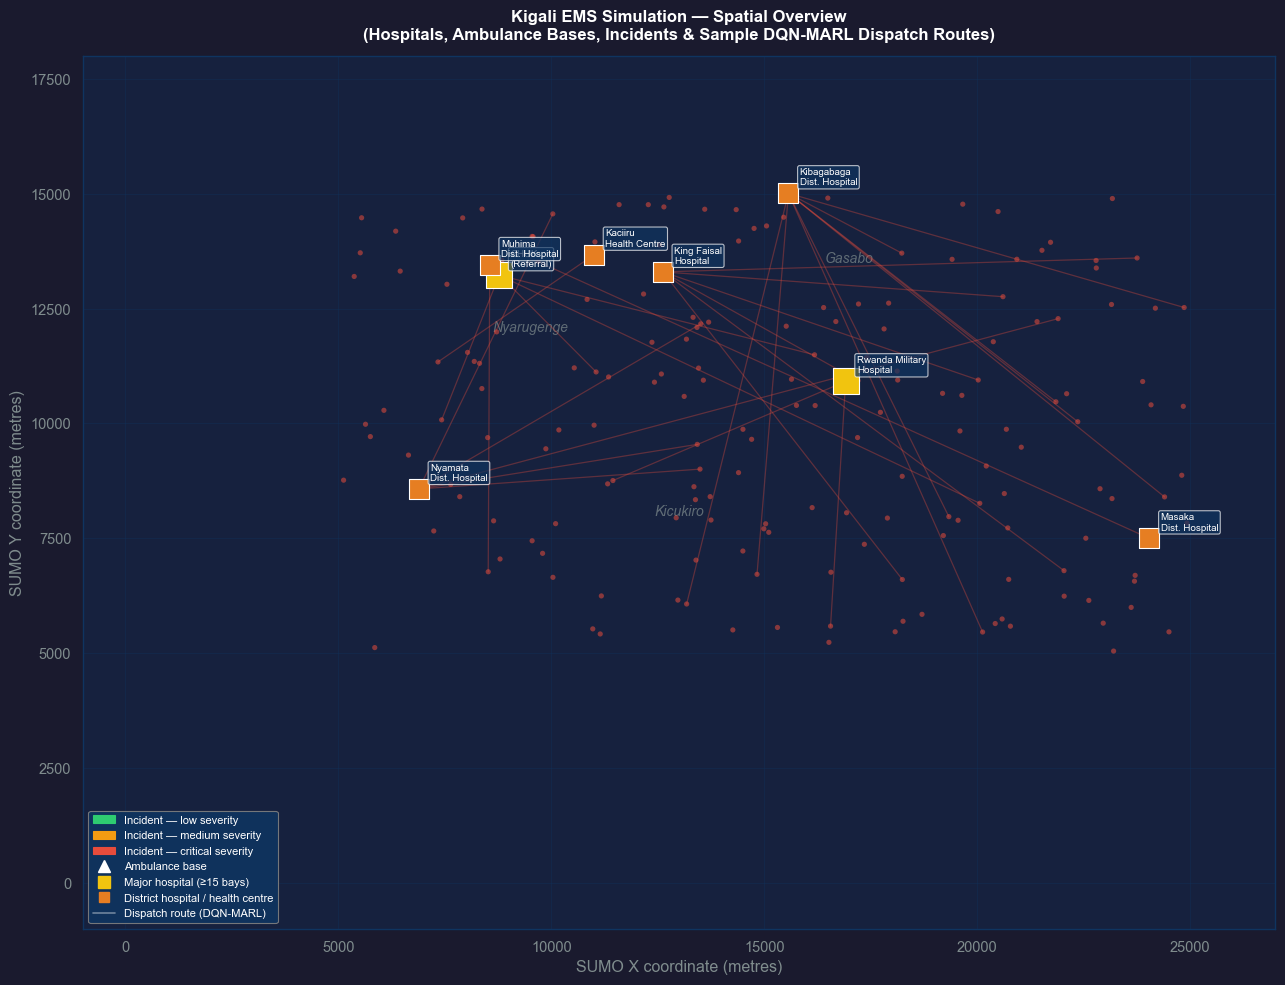

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import json
from pathlib import Path


incidents_path_raw = Path('../data/processed/incidents_high_stress.json')
with open(incidents_path_raw) as f:
    all_incidents = json.load(f)


HOSPITALS = [
    dict(id='CHUK',  name='CHUK\n(Referral)',   x=8777.2,  y=13225.8, bays=20, icon='H'),
    dict(id='KFH',   name='King Faisal\nHospital', x=12618.8, y=13298.9, bays=10, icon='H'),
    dict(id='RMH',   name='Rwanda Military\nHospital', x=16910.0, y=10915.7, bays=15, icon='H'),
    dict(id='KIB',   name='Kibagabaga\nDist. Hospital', x=15566.8, y=15008.3, bays=8,  icon='h'),
    dict(id='NYA',   name='Nyamata\nDist. Hospital',    x=6892.3,  y=8574.0,  bays=8,  icon='h'),
    dict(id='KAC',   name='Kaciiru\nHealth Centre',     x=11003.5, y=13672.4, bays=8,  icon='h'),
    dict(id='MAS',   name='Masaka\nDist. Hospital',     x=24042.0, y=7497.3,  bays=8,  icon='h'),
    dict(id='MUH',   name='Muhima\nDist. Hospital',     x=8554.1,  y=13446.8, bays=6,  icon='h'),
]

AMB_BASES = [
    (8777.2, 13225.8), (8777.2, 13225.8), (8777.2, 13225.8),
    (16910.0, 10915.7), (16910.0, 10915.7),
    (12618.8, 13298.9), (12618.8, 13298.9),
    (15566.8, 15008.3), (6892.3, 8574.0),
    (11003.5, 13672.4), (24042.0, 7497.3), (8554.1, 13446.8),
]


def severity_color(s):
    if s < 0.33:   return '#2ecc71' 
    elif s < 0.66: return '#f39c12'  
    else:          return '#e74c3c'   
inc_x = [i['x'] for i in all_incidents]
inc_y = [i['y'] for i in all_incidents]
inc_c = [severity_color(i['severity']) for i in all_incidents]



AI_POLICY  = '3 | DQN-MARL (Integrated)'
routes = []
if AI_POLICY in all_telemetry:
    inc_df = all_telemetry[AI_POLICY].get_incident_df()
    claimed = inc_df[inc_df['status'] == 'CLAIMED'].head(30)
    for _, row in claimed.iterrows():
        if row['assigned_vehicle'] is not None:
            amb_idx = int(str(row['assigned_vehicle']).replace('AMB_', ''))
            bx, by  = AMB_BASES[amb_idx % len(AMB_BASES)]
            inc_id  = int(str(row['incident_id']).split('_')[-1])
            if inc_id < len(all_incidents):
                routes.append((bx, by, all_incidents[inc_id]['x'], all_incidents[inc_id]['y'],
                                all_incidents[inc_id]['severity']))


fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')


ax.set_xlim(-1000, 27000)
ax.set_ylim(-1000, 18000)
ax.grid(True, color='#0f3460', linewidth=0.4, alpha=0.6)


for bx, by, ix, iy, sev in routes:
    ax.plot([bx, ix], [by, iy],
            color=severity_color(sev), alpha=0.35, linewidth=0.9, zorder=2)


scatter = ax.scatter(inc_x, inc_y, c=inc_c, s=14, alpha=0.55, zorder=3,
                     edgecolors='none', label='Incidents')


bx_all = [b[0] for b in AMB_BASES]
by_all = [b[1] for b in AMB_BASES]
ax.scatter(bx_all, by_all, c='#00d4ff', s=40, marker='^',
           zorder=5, alpha=0.9, label='Ambulance base')


for h in HOSPITALS:
    size   = 350 if h['bays'] >= 15 else 200
    colour = '#f1c40f' if h['bays'] >= 15 else '#e67e22'
    ax.scatter(h['x'], h['y'], c=colour, s=size, marker='s',
               zorder=6, edgecolors='white', linewidths=0.8)
    ax.annotate(h['name'],
                xy=(h['x'], h['y']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=7, color='white', zorder=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='#0f3460', alpha=0.7))


for label, lx, ly in [
    ('Nyarugenge', 9500, 12000),
    ('Gasabo',     17000, 13500),
    ('Kicukiro',   13000, 8000),
]:
    ax.text(lx, ly, label, fontsize=10, color='#7f8c8d',
            ha='center', style='italic', alpha=0.7, zorder=1)


legend_handles = [
    mpatches.Patch(color='#2ecc71',  label='Incident — low severity'),
    mpatches.Patch(color='#f39c12',  label='Incident — medium severity'),
    mpatches.Patch(color='#e74c3c',  label='Incident — critical severity'),
    mlines.Line2D([],  [], color='white',   marker='^', markersize=8,
                  linestyle='None',          label='Ambulance base'),
    mlines.Line2D([],  [], color='#f1c40f', marker='s', markersize=9,
                  linestyle='None',          label='Major hospital (≥15 bays)'),
    mlines.Line2D([],  [], color='#e67e22', marker='s', markersize=7,
                  linestyle='None',          label='District hospital / health centre'),
    mlines.Line2D([0], [1], color='white',  alpha=0.4, linewidth=1.2,
                  label='Dispatch route (DQN-MARL)'),
]
ax.legend(handles=legend_handles, loc='lower left',
          facecolor='#0f3460', edgecolor='gray',
          labelcolor='white', fontsize=8, framealpha=0.9)

ax.set_title('Kigali EMS Simulation — Spatial Overview\n'
             '(Hospitals, Ambulance Bases, Incidents & Sample DQN-MARL Dispatch Routes)',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('SUMO X coordinate (metres)', color='#7f8c8d')
ax.set_ylabel('SUMO Y coordinate (metres)', color='#7f8c8d')
ax.tick_params(colors='#7f8c8d')
for spine in ax.spines.values():
    spine.set_edgecolor('#0f3460')

plt.tight_layout()
plt.savefig('../figures/05_kigali_map.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


## 5. Response Time by Severity & Policy

The heatmap shows mean response time (seconds) broken down by **incident
severity tier** and **dispatch policy**. The DQN-MARL agent is expected to
show the largest improvement on critical-severity incidents.


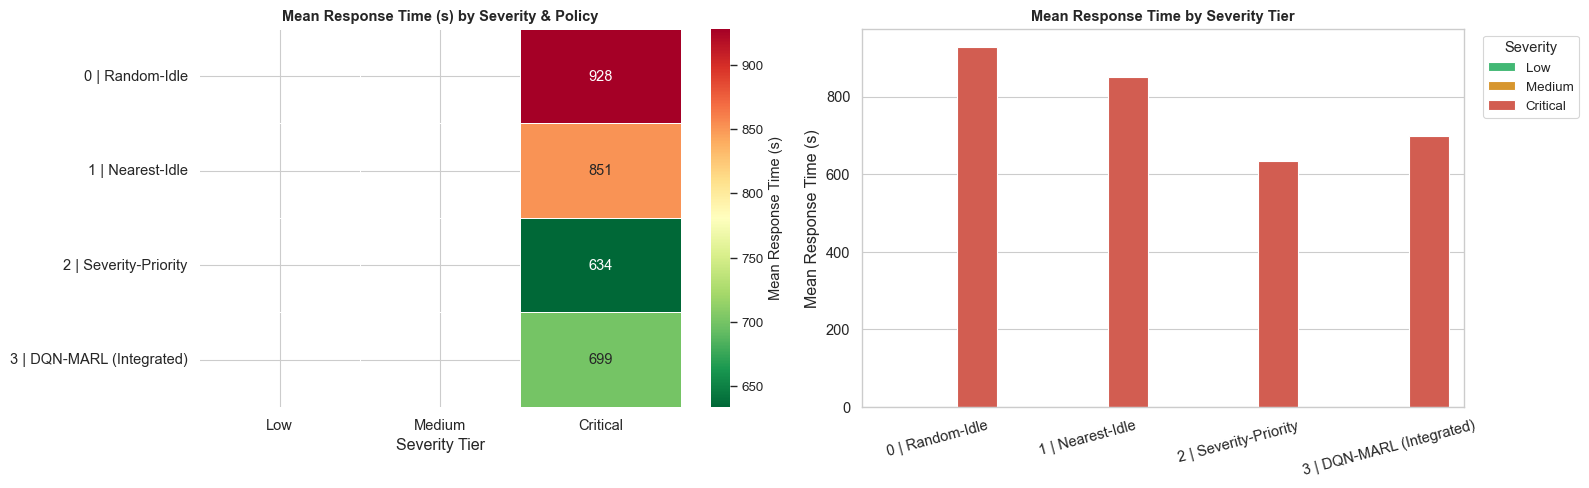

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path


with open(Path('../data/processed/incidents_high_stress.json')) as f:
    raw_inc = json.load(f)

sev_map = {}
for idx, inc in enumerate(raw_inc):
    iid = f"KGL_RTI_{idx:04d}"
    s = inc.get('severity', 0.5)
    if s < 0.33:    tier = 'Low'
    elif s < 0.66:  tier = 'Medium'
    else:           tier = 'Critical'
    sev_map[iid] = tier


rows = []
for policy, tel in all_telemetry.items():
    inc_df = tel.get_incident_df()
    reached = inc_df[inc_df['status'] == 'REACHED'][['incident_id', 'response_time_s']].dropna()
    for _, r in reached.iterrows():
        rows.append({
            'Policy':   policy,
            'Severity': sev_map.get(r['incident_id'], 'Unknown'),
            'RT (s)':   r['response_time_s'],
        })

rt_detail = pd.DataFrame(rows)

if not rt_detail.empty:
    pivot = (
        rt_detail.groupby(['Policy', 'Severity'])['RT (s)']
        .mean()
        .unstack('Severity')
        .reindex(columns=['Low', 'Medium', 'Critical'])
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)


    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
                linewidths=0.5, ax=axes[0],
                cbar_kws={'label': 'Mean Response Time (s)'})
    axes[0].set_title('Mean Response Time (s) by Severity & Policy', fontweight='bold')
    axes[0].set_xlabel('Severity Tier')
    axes[0].set_ylabel('')
    axes[0].tick_params(axis='y', rotation=0)


    pivot_reset = pivot.reset_index().melt(id_vars='Policy', var_name='Severity', value_name='Mean RT (s)')
    sev_order   = ['Low', 'Medium', 'Critical']
    palette     = {'Low': '#2ecc71', 'Medium': '#f39c12', 'Critical': '#e74c3c'}
    sns.barplot(data=pivot_reset, x='Policy', y='Mean RT (s)',
                hue='Severity', hue_order=sev_order,
                palette=palette, ax=axes[1])
    axes[1].set_title('Mean Response Time by Severity Tier', fontweight='bold')
    axes[1].set_ylabel('Mean Response Time (s)')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].legend(title='Severity', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('../figures/05_severity_response_time.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No response-time data available — run the benchmark evaluation first.')
